# Data Preprocessing

## Importing Libraries

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import linkage, dendrogram

import kagglehub
import glob

## Handling Missing Values

In [61]:
path = kagglehub.dataset_download("saurabhbadole/bank-customer-churn-prediction-dataset")

csv_path = glob.glob(f"{path}/*.csv")[0]

df = pd.read_csv(csv_path)

In [62]:
df.shape

(10000, 14)

In [63]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [65]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [66]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

## Outlier Detection & Handling

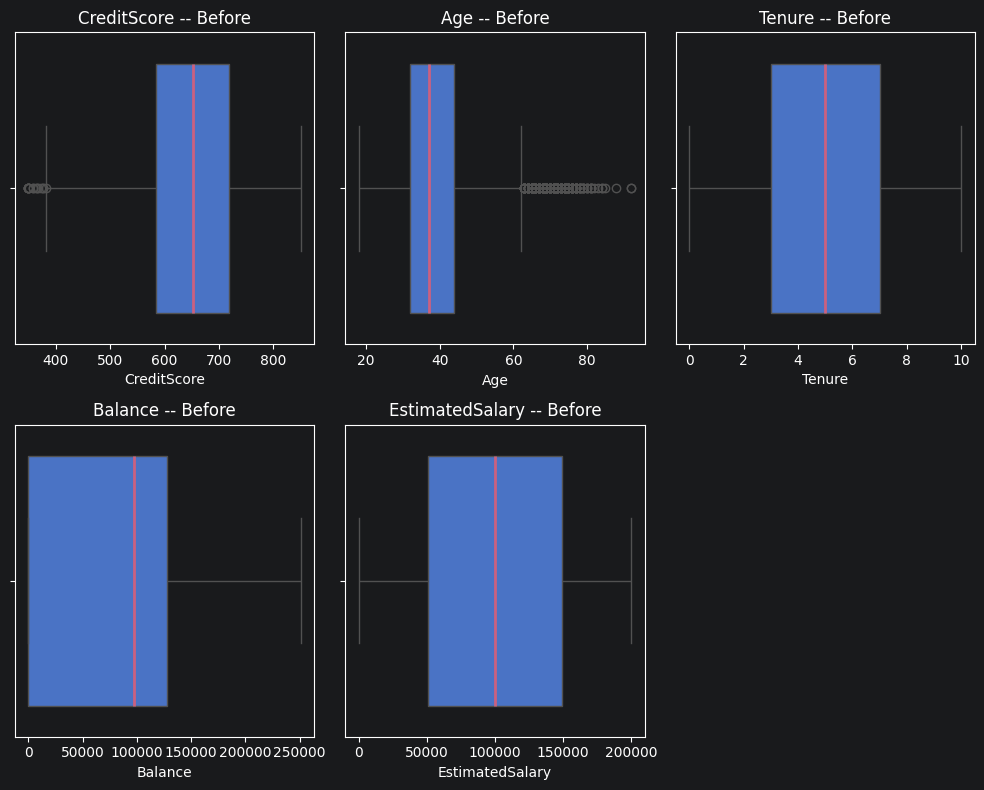

In [67]:
# continuous variables
continuous_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

# Detecting Outliers using boxplot
cols = 3
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(10, 4*rows))
axes = axes.flatten()


for i, col in enumerate(continuous_features):
    sns.boxplot(
        x=df[col],
        ax=axes[i],
        medianprops={"color": "#CA6180", "linewidth": 2}
    )
    axes[i].set_title(f'{col} -- Before')

# Removing empty subplots
for j in range(len(continuous_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [68]:
X = df.drop(columns=['Exited'])
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [69]:
# Clipping Values out of IQR range
cols_with_outliers = ["Age","CreditScore"]

for col in cols_with_outliers:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X_train[col] = X_train[col].clip(lower=lower, upper=upper)
    X_test[col] = X_test[col].clip(lower=lower, upper=upper)

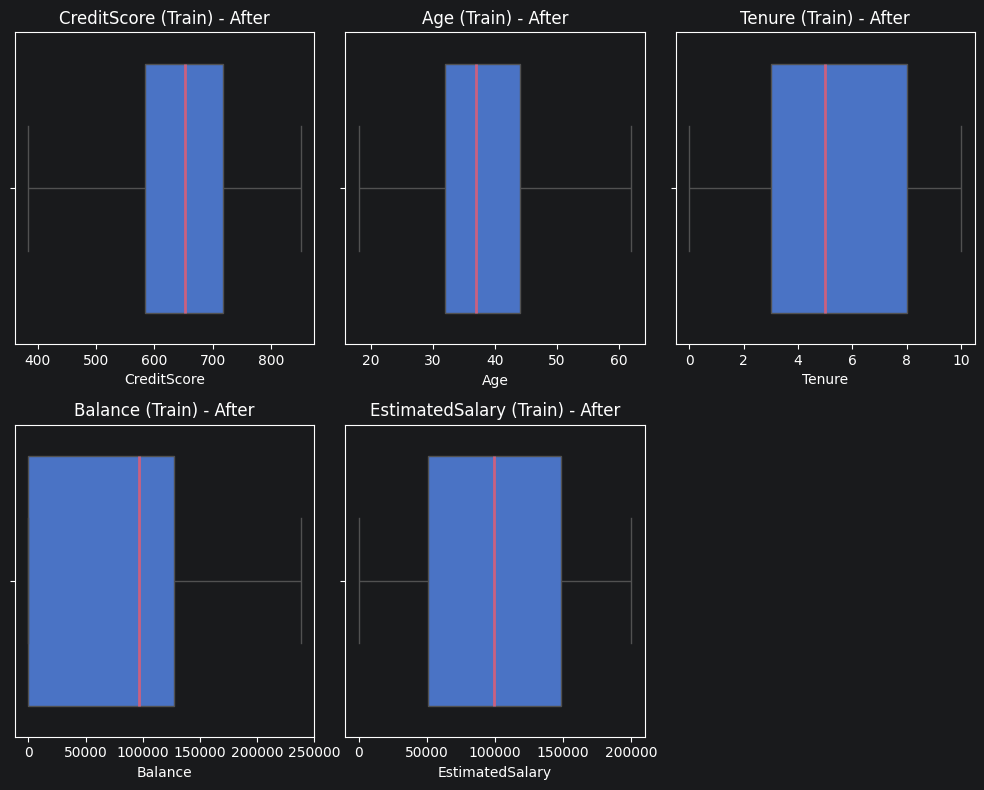

In [70]:
fig, axes = plt.subplots(rows, cols, figsize=(10, 4*rows))
axes = axes.flatten()


for i, col in enumerate(continuous_features):
    sns.boxplot(
        x=X_train[col],
        ax=axes[i],
        medianprops={"color": "#CA6180", "linewidth": 2}
    )
    axes[i].set_title(f'{col} (Train) - After')

# Removing empty subplots
for j in range(len(continuous_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

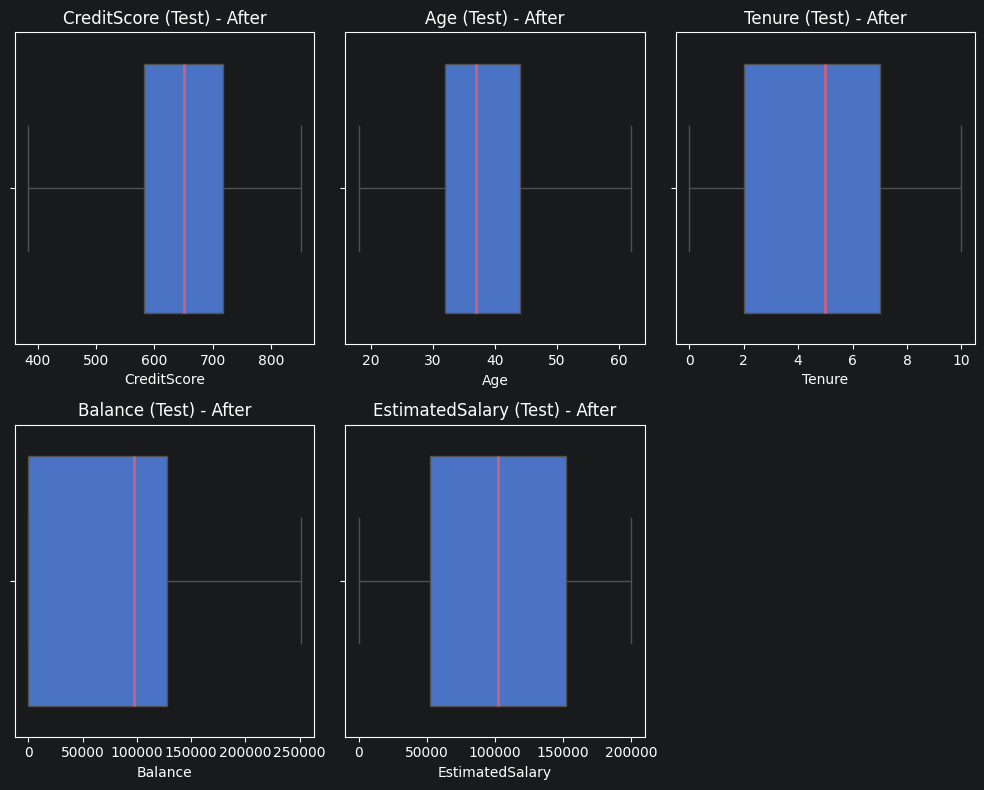

In [71]:
fig, axes = plt.subplots(rows, cols, figsize=(10, 4*rows))
axes = axes.flatten()


for i, col in enumerate(continuous_features):
    sns.boxplot(
        x=X_test[col],
        ax=axes[i],
        medianprops={"color": "#CA6180", "linewidth": 2}
    )
    axes[i].set_title(f'{col} (Test) - After')

# Removing empty subplots
for j in range(len(continuous_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [72]:
X_train_unscaled = X_train.copy()

## Scaling

In [73]:
cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

scaler = MinMaxScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [74]:
X_train.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,0.572046,0.469835,0.501663,0.320408,0.176500,0.708750,0.514875,0.498644
std,0.207293,0.221578,0.289679,0.261348,0.193914,0.454367,0.499810,0.286703
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.428571,0.318182,0.300000,0.000000,0.000000,0.000000,0.000000,0.253425
50%,0.574651,0.431818,0.500000,0.407132,0.000000,1.000000,1.000000,0.497224
75%,0.714286,0.590909,0.800000,0.535402,0.333333,1.000000,1.000000,0.742652
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Encoding

In [75]:
encoder = OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore')

cat_cols = ['Geography', 'Gender']

X_train_cat_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_cat_encoded = encoder.transform(X_test[cat_cols])

encoded_cols = encoder.get_feature_names_out(cat_cols)

X_train_cat_encoded = pd.DataFrame(X_train_cat_encoded, columns=encoded_cols, index=X_train.index)
X_test_cat_encoded = pd.DataFrame(X_test_cat_encoded, columns=encoded_cols, index=X_test.index)


In [76]:
X_train_cat_encoded.info()

<class 'pandas.DataFrame'>
Index: 8000 entries, 2151 to 6206
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Geography_France   8000 non-null   float64
 1   Geography_Germany  8000 non-null   float64
 2   Geography_Spain    8000 non-null   float64
 3   Gender_Male        8000 non-null   float64
dtypes: float64(4)
memory usage: 312.5 KB


In [77]:
X_train_cat_encoded.head()

,Geography_France,Geography_Germany,Geography_Spain,Gender_Male
2151,1.0,0.0,0.0,1.0
8392,0.0,1.0,0.0,1.0
5006,0.0,1.0,0.0,0.0
4117,1.0,0.0,0.0,1.0
7182,0.0,1.0,0.0,1.0


In [78]:
bi_cols = ['HasCrCard', 'IsActiveMember']

X_train_final = pd.concat([X_train[cols_to_scale], X_train_cat_encoded, X_train[bi_cols]], axis=1)
X_test_final = pd.concat([X_test[cols_to_scale], X_test_cat_encoded, X_test[bi_cols]], axis=1)

In [79]:
X_train_final.info()

<class 'pandas.DataFrame'>
Index: 8000 entries, 2151 to 6206
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        8000 non-null   float64
 1   Age                8000 non-null   float64
 2   Tenure             8000 non-null   float64
 3   Balance            8000 non-null   float64
 4   NumOfProducts      8000 non-null   float64
 5   EstimatedSalary    8000 non-null   float64
 6   Geography_France   8000 non-null   float64
 7   Geography_Germany  8000 non-null   float64
 8   Geography_Spain    8000 non-null   float64
 9   Gender_Male        8000 non-null   float64
 10  HasCrCard          8000 non-null   int64  
 11  IsActiveMember     8000 non-null   int64  
dtypes: float64(10), int64(2)
memory usage: 812.5 KB


In [80]:
X_train_final.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard,IsActiveMember
2151,0.791622,0.886364,0.7,0.000000,0.000000,0.797394,1.0,0.0,0.0,1.0,1,0
8392,0.761547,0.318182,0.3,0.428413,0.000000,0.319879,0.0,1.0,0.0,1.0,1,0
5006,0.795918,0.431818,0.0,0.477648,0.333333,0.586979,0.0,1.0,0.0,0.0,1,1
4117,0.379162,0.431818,0.5,0.000000,0.333333,0.415448,1.0,0.0,0.0,1.0,1,0
7182,0.660580,0.704545,0.6,0.463700,0.333333,0.537358,0.0,1.0,0.0,1.0,0,1


In [81]:
X_train_final.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard,IsActiveMember
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,0.572046,0.469835,0.501663,0.320408,0.176500,0.498644,0.499125,0.250625,0.250250,0.548375,0.708750,0.514875
std,0.207293,0.221578,0.289679,0.261348,0.193914,0.286703,0.500030,0.433400,0.433184,0.497685,0.454367,0.499810
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.428571,0.318182,0.300000,0.000000,0.000000,0.253425,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.574651,0.431818,0.500000,0.407132,0.000000,0.497224,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,0.714286,0.590909,0.800000,0.535402,0.333333,0.742652,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Dimensionality Reduction

In [82]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_final)
X_test_pca = pca.transform(X_test_final)

print(f"New number of dimensions: {X_train_pca.shape[1]}")

New number of dimensions: 9


In [83]:
X_train_pca.shape

(8000, 9)

# Hierarchical Clustering


Calculating for ward linkage...

Calculating for complete linkage...

Calculating for average linkage...


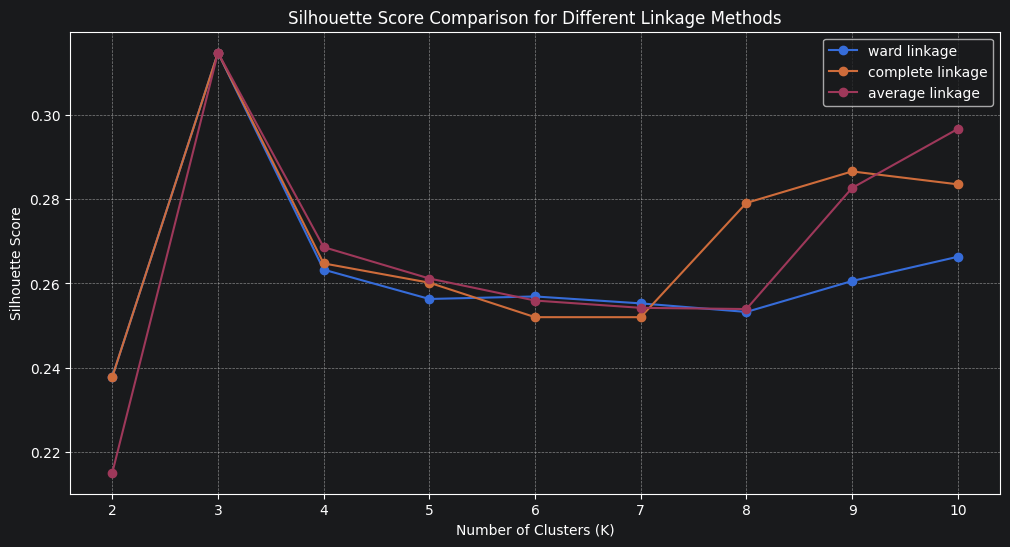


Best Results for Each Linkage Method:
ward: Best Silhouette Score = 0.3149 at K = 3
complete: Best Silhouette Score = 0.3149 at K = 3
average: Best Silhouette Score = 0.3149 at K = 3

Selected Linkage Method: ward
Optimal Number of Clusters (K): 3


In [84]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Define the linkage methods to compare
linkage_methods = ['ward', 'complete', 'average']

# Create figure for plotting
plt.figure(figsize=(12, 6))

# Dictionary to store best results for each method
results = {}

# Loop through each linkage method
for method in linkage_methods:
    silhouette_scores = []
    k_range = range(2, 11)

    print(f"\nCalculating for {method} linkage...")

    # Try different values of K
    for k in k_range:
        # Create and fit the model
        hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage=method)
        labels = hc.fit_predict(X_train_pca)

        # Calculate silhouette score
        score = silhouette_score(X_train_pca, labels)
        silhouette_scores.append(score)

    # Plot silhouette scores for this method
    plt.plot(k_range, silhouette_scores, marker='o', label=f'{method} linkage')

    # Get the best score and corresponding K for this method
    best_score = max(silhouette_scores)
    best_k = k_range[silhouette_scores.index(best_score)]

    # Store results
    results[method] = (best_score, best_k)

# Customize the plot
plt.title('Silhouette Score Comparison for Different Linkage Methods')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Print best result for each method
print("\nBest Results for Each Linkage Method:")
for method, (score, k) in results.items():
    print(f"{method}: Best Silhouette Score = {score:.4f} at K = {k}")

# Select the best method based on highest silhouette score
best_method = max(results, key=lambda x: results[x][0])
best_k = results[best_method][1]

print(f"\nSelected Linkage Method: {best_method}")
print(f"Optimal Number of Clusters (K): {best_k}")

 Linkage Method Selection

Three linkage methods (Ward, Complete, and Average) were evaluated using the Silhouette Score.

Based on the results, the Ward method achieved the highest silhouette score compared to the other methods.

Therefore, Ward linkage was selected as the optimal method.

The optimal number of clusters was found to be K = 3.

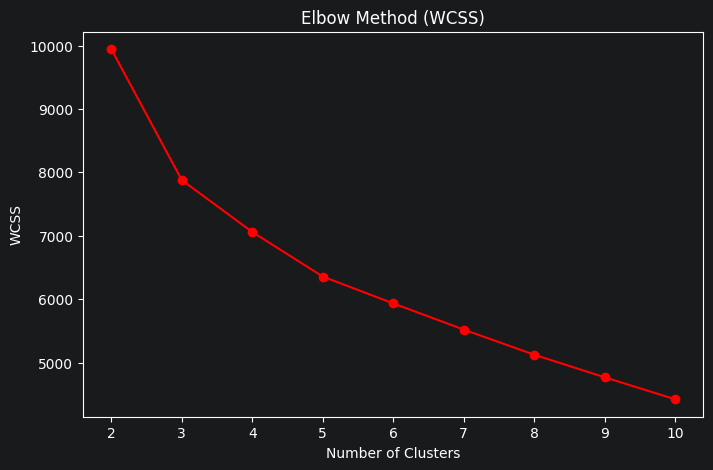

In [85]:
# Calculating WCSS for Elbow Method (Simple Loop)
wcss_scores = []
k_range = range(2, 11)

for k in k_range:
    hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = hc.fit_predict(X_train_pca)

    # Calculating Centroids manually
    centroids = []
    for i in range(k):
        # Taking mean of points in each cluster
        centroids.append(X_train_pca[labels == i].mean(axis=0))
    centroids = np.array(centroids)

    # Calculating WCSS (Sum of squared distances)
    wcss = 0
    for i in range(k):
        cluster_points = X_train_pca[labels == i]
        wcss += np.sum((cluster_points - centroids[i]) ** 2)
    wcss_scores.append(wcss)

# Plotting Elbow
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss_scores, marker='o', color='red')
plt.title('Elbow Method (WCSS)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

The optimal number of clusters was determined using the Silhouette Score.
Different values of K (from 2 to 10) were tested, and the value that produced the highest silhouette score was selected as the optimal number of clusters.

Based on the results, the best K was found to be (3).
The Ward linkage method was used because it minimizes the variance within clusters, leading to more compact and well-separated clusters.

Best K based on Silhouette Score: 3
               CreditScore       Age    Tenure   Balance  EstimatedSalary
Cluster_Label                                                            
0                 0.570553  0.460123  0.499674  0.259237         0.498777
1                 0.574220  0.470212  0.503896  0.261343         0.491621
2                 0.572850  0.488801  0.503392  0.501207         0.505391


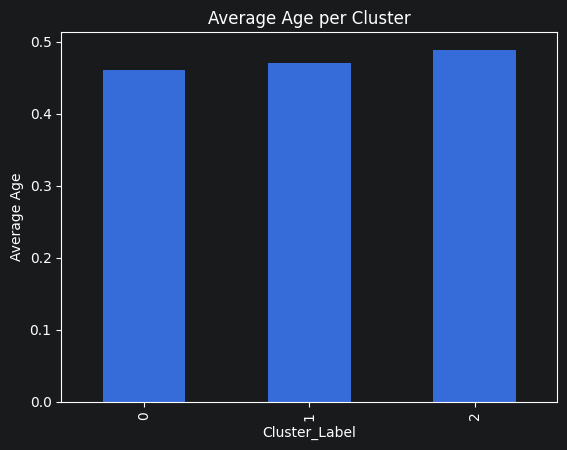

In [86]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# 1. Choosing the best K based on Silhouette Score
k_range = range(2, 11)
silhouette_scores = []

for k in k_range:
    hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = hc.fit_predict(X_train_pca)

    score = silhouette_score(X_train_pca, labels)
    silhouette_scores.append(score)

# Get the best K (highest silhouette score)
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]

print("Best K based on Silhouette Score:", best_k)

# 2. Apply Hierarchical Clustering with best K
hc_final = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='ward')
y_hc = hc_final.fit_predict(X_train_pca)

# 3. Add cluster labels to original data
X_train_copy = X_train.copy()
X_train_copy['Cluster_Label'] = y_hc

# 4. Cluster Profiling
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
cluster_profile = X_train_copy.groupby('Cluster_Label')[numeric_features].mean()

print(cluster_profile)

# 5. Simple visualization
cluster_profile['Age'].plot(kind='bar')
plt.title('Average Age per Cluster')
plt.ylabel('Average Age')
plt.show()

Cluster Interpretation

Based on the hierarchical clustering results with K = 3, the dataset was divided into three clusters. The characteristics of each cluster are interpreted as follows:

- Cluster 0 represents customers with moderate age, average balance, and average estimated salary. These customers can be considered typical or average customers.

- Cluster 1 represents customers with slightly lower balance and salary compared to other clusters, with similar age and tenure. These customers may represent lower-value or less active customers.

- Cluster 2 represents customers with higher balance and slightly higher salary compared to the other clusters. These customers can be considered high-value customers with stronger financial profiles.

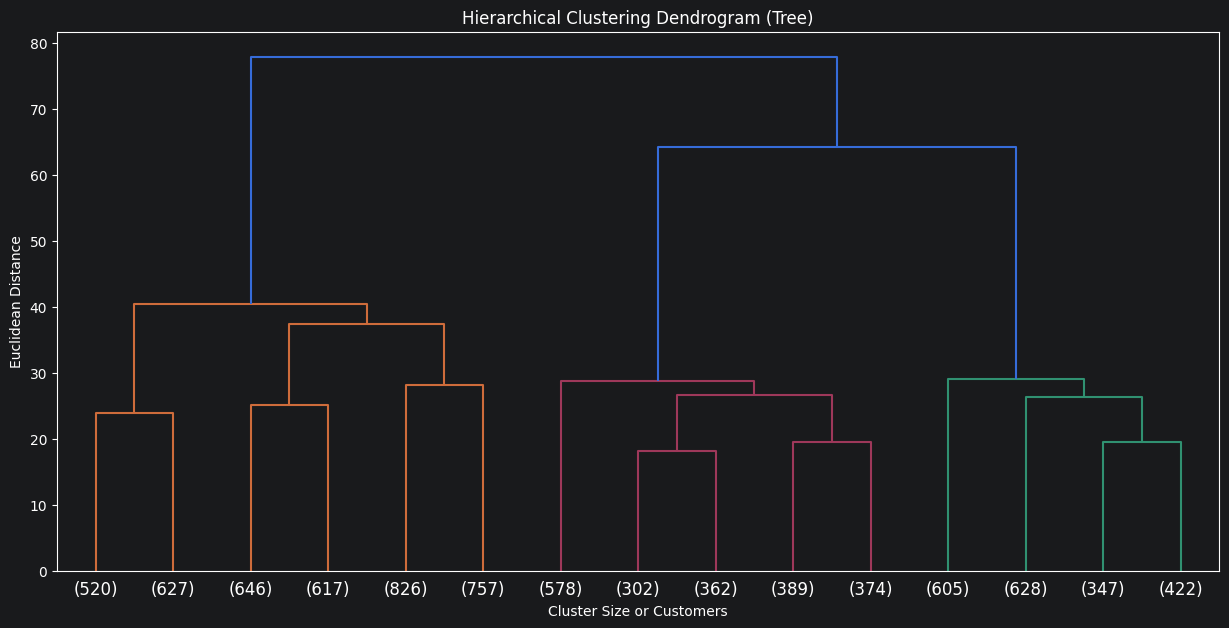

In [87]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# 1. Calculate Linkage
# 'ward' is common, but you can change to 'single' or 'complete' to see different trees
Z = sch.linkage(X_train_pca, method='ward')

# 2. Plot the Dendrogram
plt.figure(figsize=(15, 7))

# truncate_mode='lastp', p=15
dend_result = sch.dendrogram(Z, truncate_mode='lastp', p=15, show_leaf_counts=True)

plt.title('Hierarchical Clustering Dendrogram (Tree)')
plt.xlabel('Cluster Size or Customers')
plt.ylabel('Euclidean Distance')
plt.show()

# K-Medoid Clustering

In [88]:
# Choose numeric data and scalling them
X = df.select_dtypes(include=[np.number])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

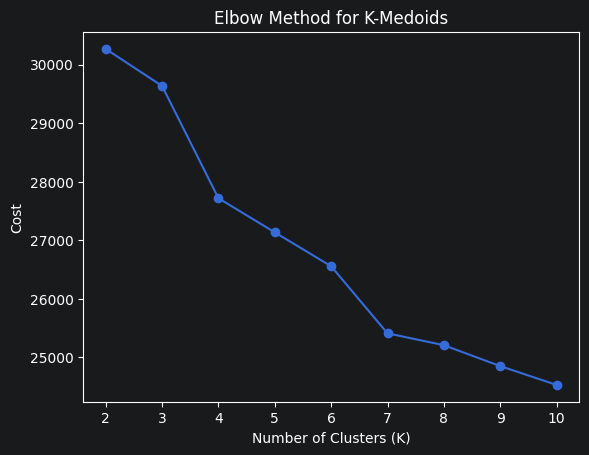

In [89]:
# Elbow Method

costs = [] # To collect all costs here

# Build K-Medoids Model
K_range = range(2,11)
for k in K_range:
  model = KMedoids(n_clusters=k, random_state=42, method='alternate')
  model.fit(X_scaled)

  cost = 0

  for i in range(len(X_scaled)): # Compute all costs
    cost += np.min(cdist([X_scaled[i]], model.cluster_centers_))

  costs.append(cost)

 # Draw Elbow Method Curve
plt.plot(K_range, costs, marker='o')
plt.title("Elbow Method for K-Medoids")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Cost")
plt.show()

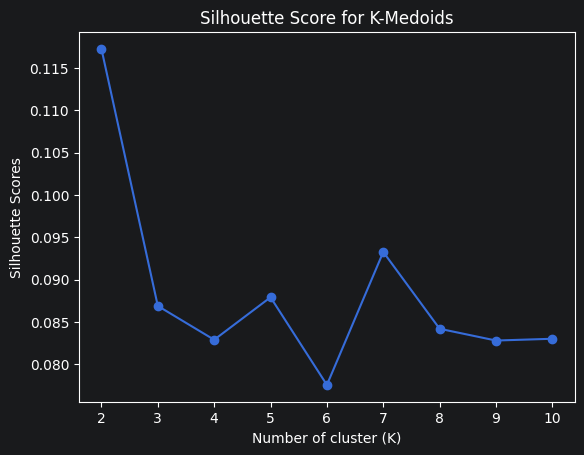

In [90]:
# Silhouette Score

sil_scores = [] # Collect all scores here

for k in K_range:
  model = KMedoids(n_clusters=k, random_state=42, method='alternate')
  labels = model.fit_predict(X_scaled) # train & get labels

  score = silhouette_score(X_scaled , labels)
  sil_scores.append(score) # All scores for all points

# Draw Silhouette score plot
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score for K-Medoids")
plt.xlabel("Number of cluster (K)")
plt.ylabel("Silhouette Scores")
plt.show()


In [91]:
# Choose the best K and Building the final model
best_k = 3 # depends on the Elbow_method & Silhouette_Score plots
final_model = KMedoids(n_clusters = best_k, random_state=42, method='alternate')
df['Cluster'] = final_model.fit_predict(X_scaled) # Add cluster column to data frame to classify which cluster each point belongs to

In [92]:
# Cluster Profiling
cluster_profile = df.select_dtypes(include=['number']).groupby('Cluster').mean()
print(cluster_profile)

         CreditScore        Age    Tenure        Balance  NumOfProducts  \
Cluster                                                                   
0         648.588010  38.259779  5.086310   51212.624152       2.079932   
1         617.768589  42.096737  6.963202  104149.322470       1.034143   
2         686.425564  36.946241  2.950000   93765.825128       1.049624   

         HasCrCard  IsActiveMember  EstimatedSalary    Exited  
Cluster                                                        
0         0.706420        0.524660    102434.142942  0.131378  
1         0.712064        0.499241     82120.846851  0.299317  
2         0.697368        0.513910    113752.495530  0.236842  


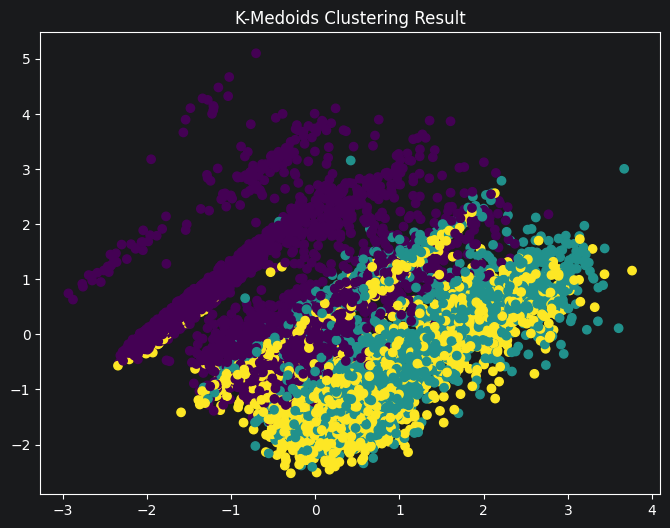

In [93]:
# Visualize the final result of K-Medoids
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='viridis')
plt.title("K-Medoids Clustering Result")
plt.show()

# GENETIC ALGORITHM

## How Genetic Algorithm working

   Genetic Algorithm is an optimization technique inspired by natural evolution It works by evolving a population of solutions over multiple generations to find the best possible solution.

 steps:

 1-Initialization

A random population of candidate solutions (chromosomes) is created.

 2-Fitness Evaluation

Each individual is evaluated using a fitness function to measure how good it is.

 3-Selection

The best individuals are selected to act as parents for the next generation.

 4-Crossover (Recombination)

Parents are combined to produce new offspring by exchanging parts of their chromosomes.

 5-Mutation

Small random changes are applied to some offspring to maintain diversity.

6-Elitism

The best solutions are preserved directly into the next generation.

 7-Replacement

The new generation replaces the old population.

 8-Termination

 The process repeats for a fixed number of generations or until convergence.
 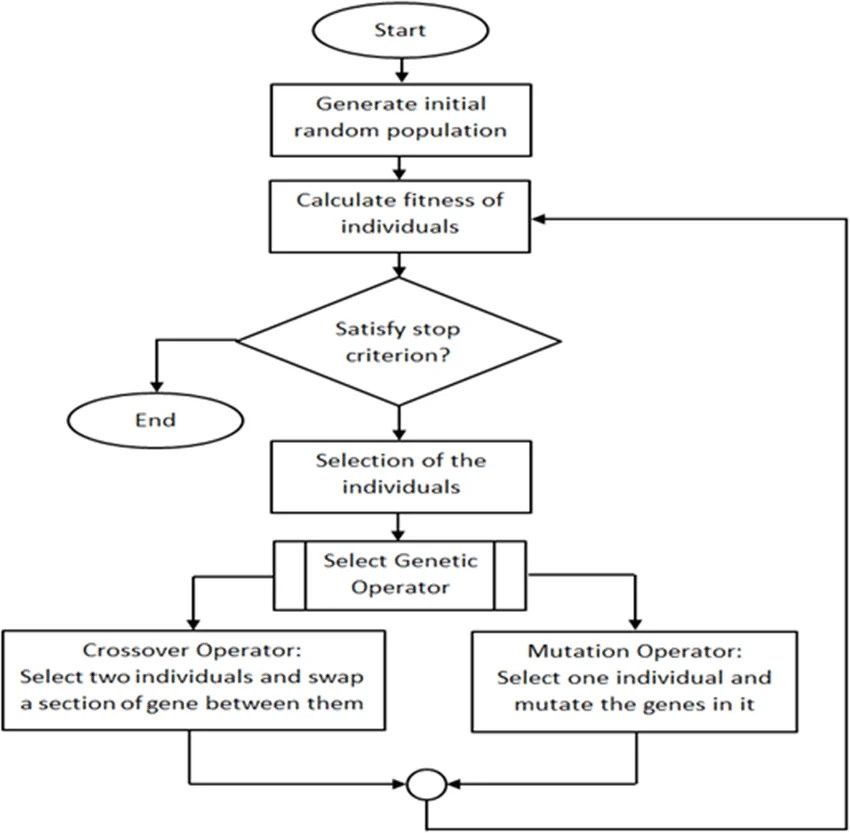
  

## GA implementation

In [94]:
# number of features in dataset will be chromosome length
num_features = X_train_final.shape[1]
#random binary chromosome 1 selected 0 not selected
def create_chromosome():
    chromosome = np.random.randint(0, 2, num_features)

   # ensure that at least one feature is selected to avoid empty solution
    if np.sum(chromosome) == 0:
        chromosome[np.random.randint(0, num_features)] = 1

    return chromosome

In [95]:
chrom = create_chromosome()
print(chrom)

[0 0 0 0 1 1 1 0 0 0 1 0]


In [96]:
def initialize_population(pop_size):
    population = []
# generate chromosomes to build the initial population
    for _ in range(pop_size):
        population.append(create_chromosome())
# convert list to array for better performance
    return np.array(population)

In [97]:
population = initialize_population(10)
print(population)

[[0 1 1 0 0 0 1 1 1 0 0 1]
 [0 0 0 1 1 1 1 1 0 1 0 1]
 [1 0 0 0 1 0 1 0 0 0 1 0]
 [0 1 0 0 0 1 0 0 1 1 1 0]
 [1 0 1 0 1 0 0 1 1 0 1 0]
 [0 1 0 0 0 1 0 1 1 0 0 1]
 [0 0 0 1 0 1 1 0 0 1 0 1]
 [0 1 0 1 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 1 0 0 1 1 0]
 [1 0 0 0 0 1 1 1 0 0 0 0]]


In [98]:
def tournament_selection(population, fitness_values, tournament_size=3):
    selected = []

    for _ in range(len(population)):
        # randomly choose individuals
        indices = np.random.choice(len(population), tournament_size, replace=False)
        # select the individual with the highest fitness in the tournament
        best_idx = indices[np.argmax([fitness_values[i] for i in indices])]

        selected.append(population[best_idx])

    return np.array(selected)

In [99]:
def crossover(parent1, parent2):
  # randomly choose a crossover point
    point = np.random.randint(1, len(parent1))

    child1 = np.concatenate((parent1[:point], parent2[point:]))
    child2 = np.concatenate((parent2[:point], parent1[point:]))

    return child1, child2

In [100]:
def mutation(chromosome, mutation_prob=0.2):
    for i in range(len(chromosome)):
        if np.random.rand() < mutation_prob:
            chromosome[i] = 1 - chromosome[i]

    return chromosome

In [101]:
def elitism(population, fitness_values, elite_size=1):
  # sorting individuals by fitness in descending order
    idx = np.argsort(fitness_values)[::-1]
    # select the top individuals
    elite = population[idx[:elite_size]]
    return elite

In [102]:
def fitness(
    chromosome,
    X=X_train_final,
    model_type="hierarchical",
    n_clusters=3,
    alpha=0.1
):
    """
    General fitness function for GA-based feature selection.
    """

    # Feature masking
    selected_idx = np.where(chromosome == 1)[0]
    if len(selected_idx) < 2:
        return -1

    X_selected = X.values[:, selected_idx]

    try:
        # Choose clustering model
        if model_type == "hierarchical":
            model = AgglomerativeClustering(
                n_clusters=n_clusters,
                metric="euclidean",
                linkage="ward"
            )

        elif model_type == "kmedoids":
            model = KMedoids(
                n_clusters=n_clusters,
                random_state=42,
                method="alternate"
            )

        else:
            raise ValueError("Unknown model type")

        labels = model.fit_predict(X_selected)

        # Evaluation
        sil = silhouette_score(X_selected, labels)

        # Penalty
        penalty = alpha * (len(selected_idx) / X.shape[1])

        return sil - penalty

    except Exception:
        return -1

In [103]:
def genetic_algorithm(pop_size, generations, model_type, mutation_prob=0.2, elite_size=1):

    population = initialize_population(pop_size)

    best_solution = population[0]
    best_fitness = fitness(best_solution)
    fitness_history = []

    for gen in range(generations):


        fitness_values = [
            fitness(ind, model_type=model_type)
            for ind in population
        ]


        # get the best individual in the current generation
        gen_best_idx = np.argmax(fitness_values)
        if fitness_values[gen_best_idx] > best_fitness:
            best_fitness = fitness_values[gen_best_idx]
            best_solution = population[gen_best_idx]

        fitness_history.append(best_fitness)

        # Elitism
        elite = elitism(population, fitness_values, elite_size)

        # Selection
        selected = tournament_selection(population, fitness_values)

        # Next generation
        new_population = list(elite)

        # Crossover + Mutation
        while len(new_population) < pop_size:
            parent1 = selected[np.random.randint(len(selected))]
            parent2 = selected[np.random.randint(len(selected))]

            child1, child2 = crossover(parent1, parent2)

            child1 = mutation(child1, mutation_prob)
            child2 = mutation(child2, mutation_prob)

            new_population.append(child1)
            if len(new_population) < pop_size:
                new_population.append(child2)

        population = np.array(new_population)

    return best_solution, best_fitness, fitness_history

In [104]:
best_solution_h, best_fitness_h, fitness_history_h = genetic_algorithm(
    pop_size=6,
    generations=15,
    model_type="hierarchical"
)
print("Hierarchical GA Fitness Evolution:")
for gen, fit in enumerate(fitness_history_h):
    print(f"Generation {gen+1}: Best Fitness = {fit:.4f}")

print("Best Solution (Hierarchical):", best_solution_h)
print("Best Fitness (Hierarchical):", best_fitness_h)

Hierarchical GA Fitness Evolution:
Generation 1: Best Fitness = 0.5992
Generation 2: Best Fitness = 0.8804
Generation 3: Best Fitness = 0.8804
Generation 4: Best Fitness = 0.8804
Generation 5: Best Fitness = 0.8804
Generation 6: Best Fitness = 0.8804
Generation 7: Best Fitness = 0.8804
Generation 8: Best Fitness = 0.8804
Generation 9: Best Fitness = 0.8804
Generation 10: Best Fitness = 0.8804
Generation 11: Best Fitness = 0.8804
Generation 12: Best Fitness = 0.8804
Generation 13: Best Fitness = 0.8804
Generation 14: Best Fitness = 0.8804
Generation 15: Best Fitness = 0.8804
Best Solution (Hierarchical): [0 0 0 0 0 0 0 1 0 0 1 0]
Best Fitness (Hierarchical): 0.880438373253493


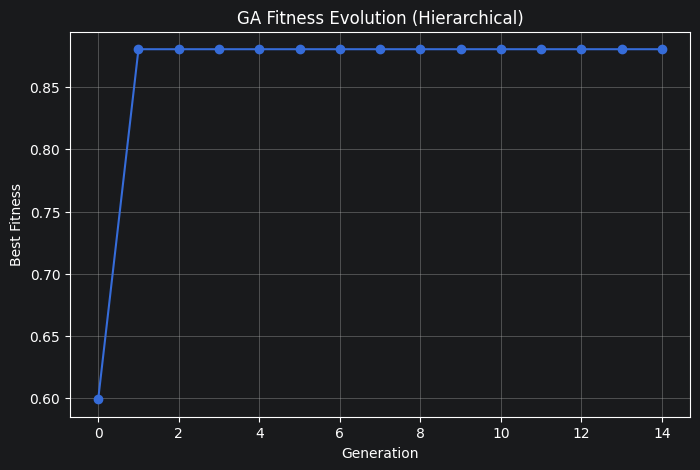

In [105]:
plt.figure(figsize=(8,5))
plt.plot(fitness_history_h, marker='o')
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("GA Fitness Evolution (Hierarchical)")
plt.grid(True)
plt.show()

In [106]:
best_solution_k, best_fitness_k, fitness_history_k = genetic_algorithm(
    pop_size=6,
    generations=15,
    model_type="kmedoids"
)
print("K-Medoids GA Fitness Evolution:")
for gen, fit in enumerate(fitness_history_k):
    print(f"Generation {gen+1}: Best Fitness = {fit:.4f}")

print("Best Solution (K-Medoids):", best_solution_k)
print("Best Fitness (K-Medoids):", best_fitness_k)

C:\Users\omari\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
C:\Users\omari\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
C:\Users\omari\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
C:\Users\omari\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cl

K-Medoids GA Fitness Evolution:
Generation 1: Best Fitness = 0.3052
Generation 2: Best Fitness = 0.3052
Generation 3: Best Fitness = 0.3052
Generation 4: Best Fitness = 0.4714
Generation 5: Best Fitness = 0.4714
Generation 6: Best Fitness = 0.4714
Generation 7: Best Fitness = 0.4714
Generation 8: Best Fitness = 0.4714
Generation 9: Best Fitness = 0.4714
Generation 10: Best Fitness = 0.4714
Generation 11: Best Fitness = 0.4714
Generation 12: Best Fitness = 0.4714
Generation 13: Best Fitness = 0.4714
Generation 14: Best Fitness = 0.4714
Generation 15: Best Fitness = 0.4714
Best Solution (K-Medoids): [0 0 0 0 1 1 0 0 0 0 0 1]
Best Fitness (K-Medoids): 0.47143187434018813


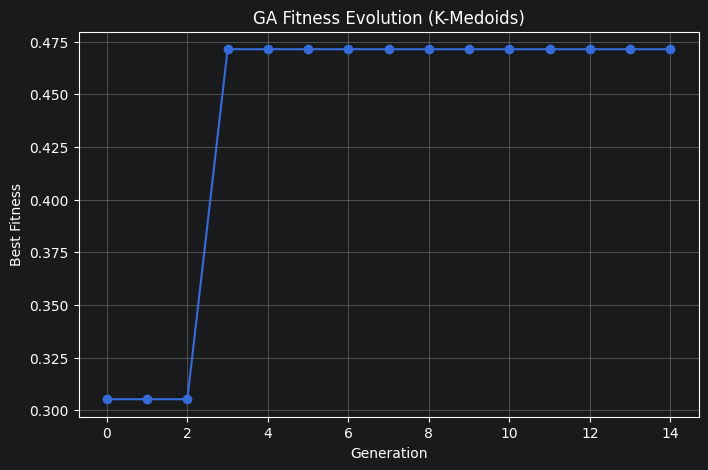

In [107]:
plt.figure(figsize=(8,5))
plt.plot(fitness_history_k, marker='o')
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("GA Fitness Evolution (K-Medoids)")
plt.grid(True)
plt.show()

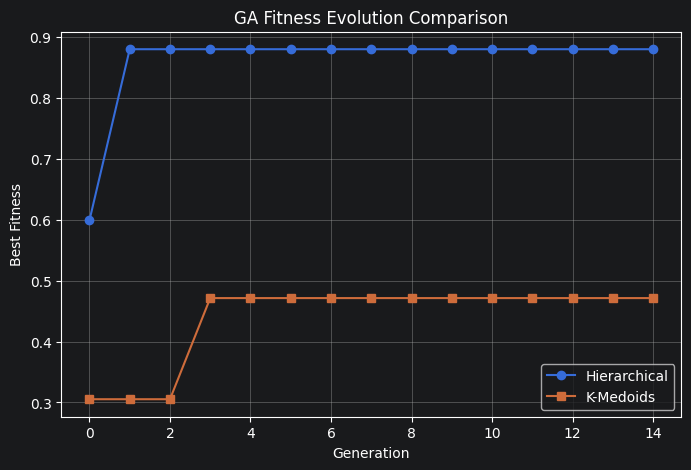

In [108]:
plt.figure(figsize=(8,5))
plt.plot(fitness_history_h, label="Hierarchical", marker='o')
plt.plot(fitness_history_k, label="K-Medoids", marker='s')
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("GA Fitness Evolution Comparison")
plt.legend()
plt.grid(True)
plt.show()

The fitness evolution curves illustrate the convergence behavior of the Genetic Algorithm for both Hierarchical and K-Medoids clustering.
In both cases, the GA demonstrates consistent improvement across generations, with Hierarchical achieving a higher final fitness value, indicating more compact and well-separated customer clusters.

## comparison to baseline

In [109]:
# Hierarchical - all features
labels_h_base = AgglomerativeClustering(
    n_clusters=3,
    metric="euclidean",
    linkage="single"
).fit_predict(X_train_final)

silhouette_h_baseline = silhouette_score(X_train_final, labels_h_base)

In [110]:
# Hierarchical - selected features from GA
selected_idx_h = np.where(best_solution_h == 1)[0]
X_h_selected = X_train_final.values[:, selected_idx_h]

hierarchical_ga = AgglomerativeClustering(
    n_clusters=3,
    metric="euclidean",
    linkage="single"
)
labels_h_ga = hierarchical_ga.fit_predict(X_h_selected)

silhouette_h_after = silhouette_score(X_h_selected, labels_h_ga)

In [111]:
Z = linkage(
    X_h_selected,
    method="single",
    metric="euclidean"
)

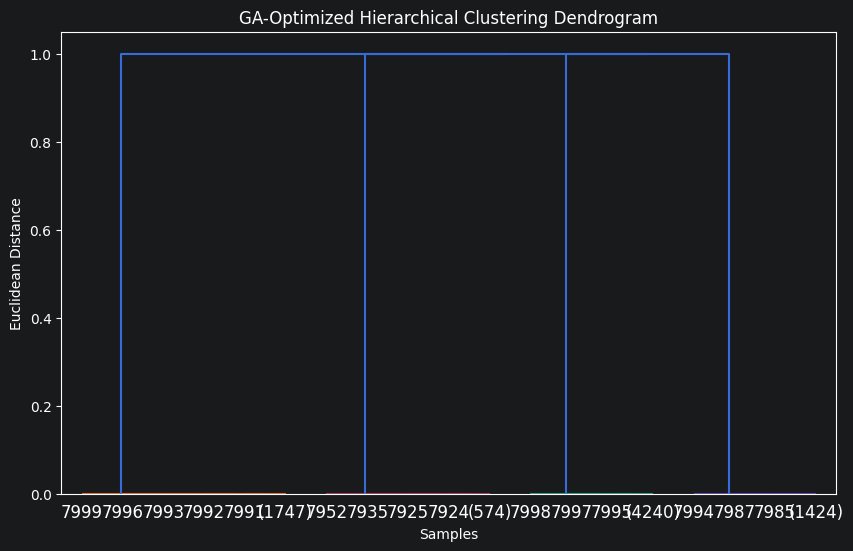

In [112]:
plt.figure(figsize=(10,6))

dendrogram(
    Z,
    truncate_mode="level",
    p=5,
    show_leaf_counts=True
)

plt.title("GA-Optimized Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Euclidean Distance")
plt.show()

In [113]:
# K-Medoids - all features
labels_k_base = KMedoids(
    n_clusters=3,
    random_state=42,
    method="alternate"
).fit_predict(X_train_final)

silhouette_k_baseline = silhouette_score(X_train_final, labels_k_base)

In [114]:
# K-Medoids - selected features from GA
selected_idx_k = np.where(best_solution_k == 1)[0]
X_k_selected = X_train_final.values[:, selected_idx_k]

kmedoids_ga = KMedoids(
    n_clusters=3,
    random_state=42,
    method="alternate"
)

labels_k_ga = kmedoids_ga.fit_predict(X_k_selected)

silhouette_k_after = silhouette_score(X_k_selected, labels_k_ga)

In [115]:
# dimesionality reduction for plot
pca_vis = PCA(n_components=2, random_state=42)
X_k_2d = pca_vis.fit_transform(X_k_selected)

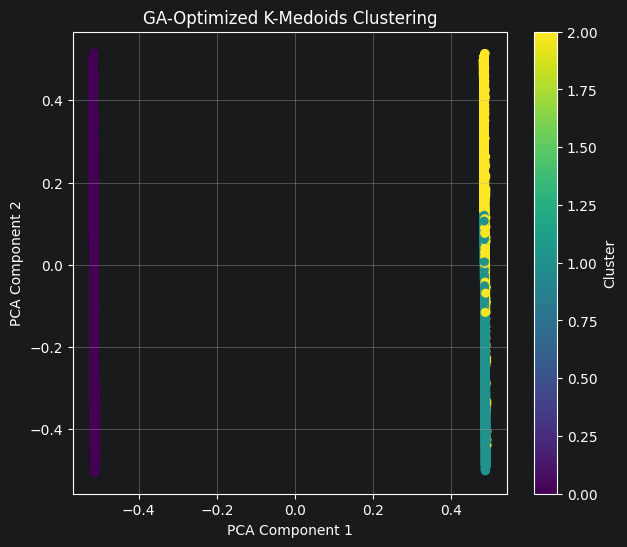

In [116]:
plt.figure(figsize=(7,6))
scatter = plt.scatter(
    X_k_2d[:, 0],
    X_k_2d[:, 1],
    c=labels_k_ga,
    cmap="viridis",
    s=30
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("GA-Optimized K-Medoids Clustering")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

The best chromosome obtained from the Genetic Algorithm was decoded into a subset of selected features, which was then used to re-evaluate clustering performance using the pure silhouette score.
This comparison against the baseline model using all features demonstrates the effectiveness of GA-based feature subset selection in improving clustering quality.

In [117]:
print("===== Silhouette Score Comparison =====\n")

print("Hierarchical Clustering:")
print(f"Silhouette Before GA (All Features): {silhouette_h_baseline:.4f}")
print(f"Silhouette After GA  (Selected Features): {silhouette_h_after:.4f}")
print(f"Improvement: {silhouette_h_after - silhouette_h_baseline:.4f}\n")

print("K-Medoids Clustering:")
print(f"Silhouette Before GA (All Features): {silhouette_k_baseline:.4f}")
print(f"Silhouette After GA  (Selected Features): {silhouette_k_after:.4f}")
print(f"Improvement: {silhouette_k_after - silhouette_k_baseline:.4f}")

===== Silhouette Score Comparison =====

Hierarchical Clustering:
Silhouette Before GA (All Features): 0.2995
Silhouette After GA  (Selected Features): 0.7330
Improvement: 0.4335

K-Medoids Clustering:
Silhouette Before GA (All Features): 0.0909
Silhouette After GA  (Selected Features): 0.4964
Improvement: 0.4056


The improved silhouette scores after GA optimization highlight the effectiveness of feature subset selection in enhancing clustering quality compared to using all features.

# FUZZY LOGIC INFERENCE SYSTEM (FIS)

## FUZZY LOGIC OVERVIEW

## INPUT 1:
The FIS will use the output from the K-Medoids model **(Assuming 3 segments: Low/Medium/High risk of churn)**
## INPUT 2:
This will be the balance of the Customer: **ZERO/Low/Medium/High balance**.
## OUTPUT (THE DECISION):
The decision our system is going to make is how much the bank will prioritize this specific customer. \
**PRIORITY:  Range: (0-100)**\
**Low Priority** customers will be provided with no action. \
**Medium Priority** customers will get an automated email or maybe a discount voucher.\
**HIGH PRIORITY (VIP PRIO)** will get an immediate manager call to try to keep the customer from churning.

## Defining fuzzy sets for balance
Balance range (after scaling) -> [0-1]\
Based on the balance distribution,

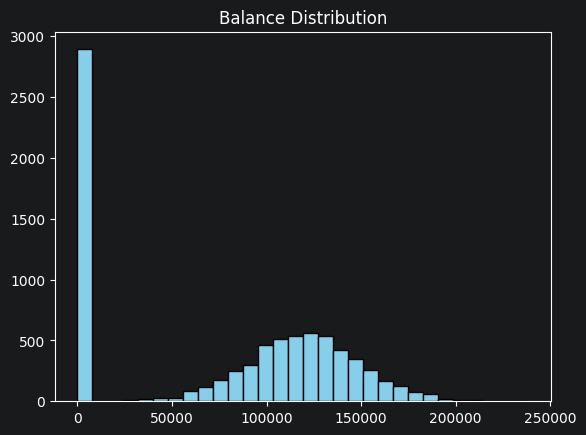

In [118]:
plt.hist(x=X_train_unscaled['Balance'], bins=30, color='skyblue', edgecolor='black')
plt.title("Balance Distribution")
plt.show()

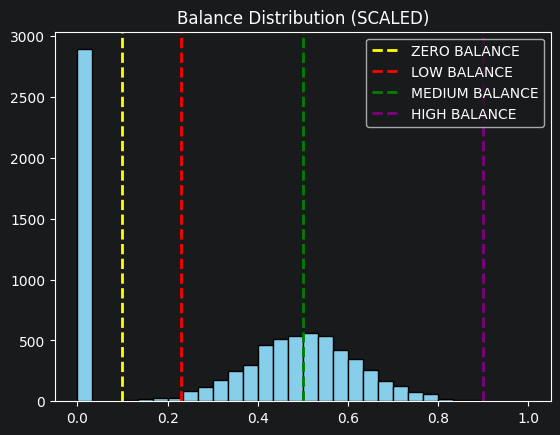

In [119]:
plt.hist(x=X_train_final['Balance'], bins=30, color='skyblue', edgecolor='black')
plt.title("Balance Distribution (SCALED)")

plt.axvline(x=.1, color='yellow', linestyle='--', linewidth=2, label="ZERO BALANCE")
plt.axvline(x=.23, color='red', linestyle='--', linewidth=2, label="LOW BALANCE")
plt.axvline(x=.5, color='green', linestyle='--', linewidth=2, label="MEDIUM BALANCE")
plt.axvline(x=.9, color='purple', linestyle='--', linewidth=2, label="HIGH BALANCE")

plt.legend()
plt.show()

## Fuzzy Sets

In [120]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import warnings
warnings.filterwarnings('ignore', category=UserWarning)


In [121]:
# Churn Risk: Range (0-1)
# Balance: Range (0-1)
balance= ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'balance')
churn_risk=ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'churn_risk')

In [122]:
# PRIORITY SCORE (0-100)
priority = ctrl.Consequent(np.arange(0, 101, 1), 'priority')

## Membership Functions

#### 1. Input Variable: Balance
Based on the histogram analysis, the following membership functions are defined to handle the input from account balance

| Fuzzy Set | Shape | Coordinates | Logic |
| :--- | :--- | :--- | :--- |
| **Dust/Zero** | Trapezoid | $[0, 0, 0.05, 0.1]$ | Customer with zero (or near zero) funds |
| **Low** | Triangle | $[0.05, 0.2, 0.4]$ | Small accounts with low funds |
| **Medium** | Triangle | $[0.3, 0.5, 0.7]$ | Average customers |
| **High** | Trapezoid | $[0.6, 0.8, 1.0, 1.0]$ | VIPs and High-value individuals |

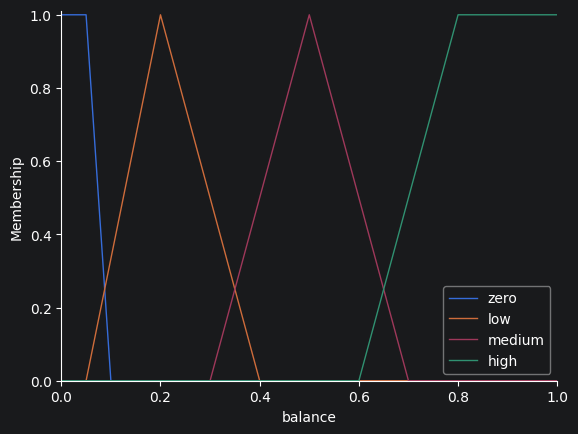

In [123]:
# MF BALANCE
balance['zero']=fuzz.trapmf(balance.universe,[0,0,0.05, 0.1])
balance['low']=fuzz.trimf(balance.universe,[0.05,0.2,0.4])
balance['medium']=fuzz.trimf(balance.universe,[0.3,0.5,0.7])
balance['high']=fuzz.trapmf(balance.universe,[0.6,0.8,1.0,1.0])

balance.view()
plt.show()

#### 2. Input Variable: Cluster Risk
Mapped from K-Medoids clustering based on the churn rate of each cluster.

| Fuzzy Set | Shape | Coordinates  | Description |
| :--- | :--- | :--- | :--- |
| **Low Risk** | Triangle | $[0, 0, 0.4]$ | Cluster with the lowest churn rate. |
| **Medium Risk** | Triangle | $[.2, 0.5, .8]$ | Cluster with moderate churn rate. |
| **Critical** | Triangle | $[0.6, 1, 1]$ | Cluster with the highest churn rate. |

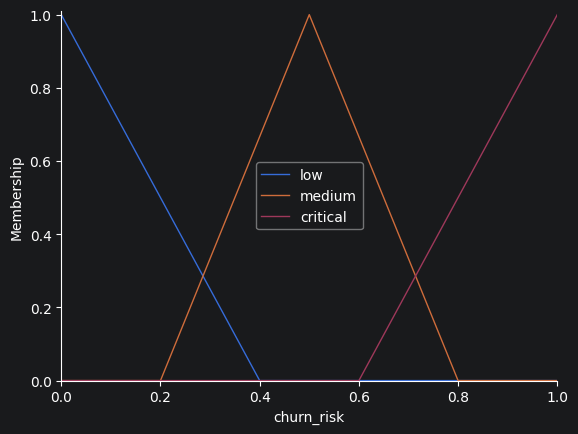

In [124]:
# MF FOR RISK
churn_risk['low'] = fuzz.trimf(churn_risk.universe, [0, 0, 0.4])
churn_risk['medium'] = fuzz.trimf(churn_risk.universe, [0.2, 0.5, 0.8])
churn_risk['critical'] = fuzz.trimf(churn_risk.universe, [0.6, 1.0, 1.0])

churn_risk.view()
plt.show()

#### 3. Output Variable: Priority Score (0-100)
How hard is the bank going to try to keep the customer from churning

| Fuzzy Set | Shape | Coordinates | Action / Decision |
| :--- | :--- | :--- | :--- |
| **Low Prio** | Trapezoid | $[0, 0, 20, 40]$ | No resources spent |
| **Med Prio** | Triangle | $[30, 50, 70]$ | Automated marketing email or discount offers. |
| **High Prio (VIP)** | Trapezoid | $[60, 80, 100, 100]$ | Call from mangement or sales team |

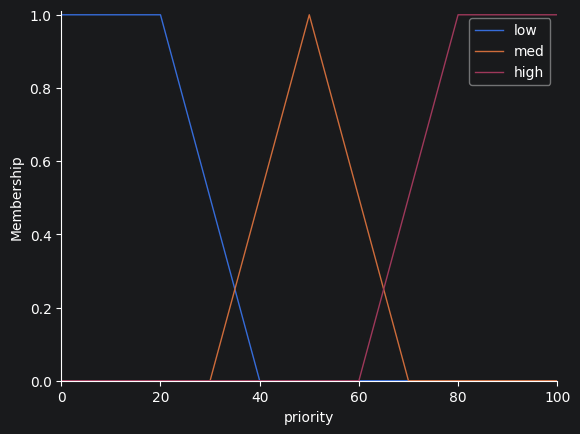

In [125]:
# MF FOR Priority Score
priority['low'] = fuzz.trapmf(priority.universe, [0, 0, 20, 40])
priority['med'] = fuzz.trimf(priority.universe, [30, 50, 70])
priority['high'] = fuzz.trapmf(priority.universe, [60, 80, 100, 100])


priority.view()
plt.show()

## **Fuzzy Rules**

| Rule # | IF Cluster Risk is... | AND Account Balance is... | THEN Retention Priority is... |
| :--- | :--- | :--- | :--- |
| **1** | Low Risk | Dust | **Low Prio** |
| **2** | Medium Risk | Dust | **Low Prio** |
| **3** | Critical Risk | Dust | **Low Prio** |
| **4** | Low Risk | Low | **Low Prio** |
| **5** | Low Risk | Medium | **Low Prio** |
| **6** | Low Risk | High | **Med Prio** |
| **7** | Medium Risk | Low | **Med Prio** |
| **8** | Medium Risk | Medium | **Med Prio** |
| **9** | Medium Risk | High | **High Prio (VIP)** |
| **10** | Critical Risk | Low | **Med Prio** |
| **11** | Critical Risk | Medium | **High Prio (VIP)** |
| **12** | Critical Risk | High | **High Prio (VIP)** |

---
NOTE: If the customer is in the 'have Zero', their prio will be low regardless of their risk state 

In [126]:
# fuzzy rules
rule1 = ctrl.Rule(churn_risk['critical'] & balance['zero'], priority['high'])
rule2 = ctrl.Rule(churn_risk['critical'] & balance['low'], priority['high'])
rule3 = ctrl.Rule(churn_risk['critical'] & balance['medium'], priority['high'])
rule4 = ctrl.Rule(churn_risk['critical'] & balance['high'], priority['high'])
rule5 = ctrl.Rule(churn_risk['medium'] & balance['high'], priority['high'])
rule6 = ctrl.Rule(churn_risk['medium'] & balance['medium'], priority['med'])
rule7 = ctrl.Rule(churn_risk['medium'] & balance['low'], priority['med'])
rule8 = ctrl.Rule(churn_risk['low'] & balance['high'], priority['med'])
rule9 = ctrl.Rule(churn_risk['low'] & balance['medium'], priority['low'])
rule10 = ctrl.Rule(churn_risk['low'] & balance['low'], priority['low'])
rule11 = ctrl.Rule(churn_risk['low'] & balance['zero'], priority['low'])
rule12 = ctrl.Rule(churn_risk['medium'] & balance['zero'], priority['low'])

In [127]:
# fuzzy control system
priority_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6,
    rule7, rule8, rule9, rule10, rule11, rule12
])
# fuzzy simulator
priority_sim = ctrl.ControlSystemSimulation(priority_ctrl)

Priority Score: 83.46 → Manager Call


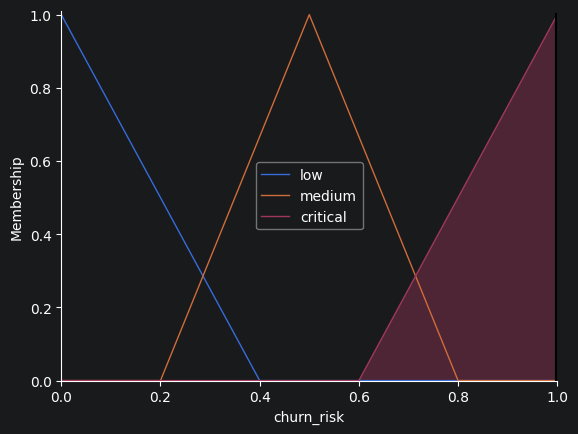

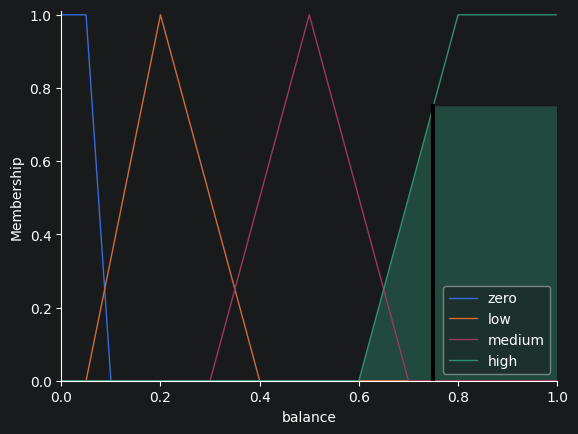

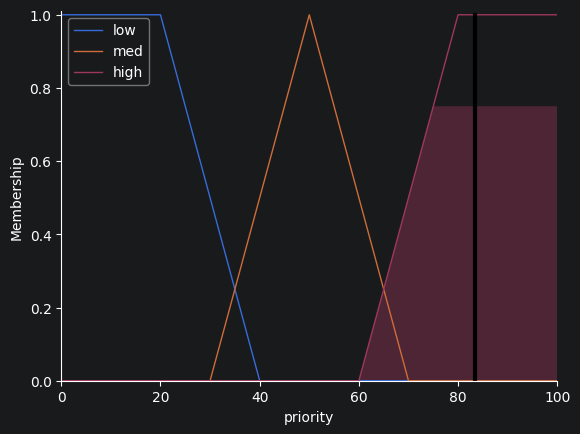

In [128]:
# skfuzzy uses centroid defuzzification by default
priority.defuzzify_method = 'centroid'

# Example: Critical risk customer with high balance
priority_sim.input['churn_risk'] = 1.0
priority_sim.input['balance'] = 0.75
priority_sim.compute()

print(f"Priority Score: {priority_sim.output['priority']:.2f} → Call from mangement/sales team")

churn_risk.view(priority_sim)
plt.show()
balance.view(priority_sim)
plt.show()
priority.view(priority_sim)
plt.show()

# TODO: INPUT 1 -> FROM KM MODEL

In [139]:
# Validate against real samples from the dataset
test_df = X_test_final.copy()
test_df['Cluster'] = df.loc[X_test_final.index, 'Cluster'].values
test_df['Exited'] = y_test.values

# group and calculate the average for each cluster
churn_rates = test_df.groupby('Cluster')['Exited'].mean().to_dict()

# Note: iterrows is pands function to loop the DF row by row
for i, row in test_df.sample(10, random_state=22).iterrows():
    balance_val = row['Balance']
    risk_val = churn_rates[int(row['Cluster'])]

    # enter the balance and churn risk into the fuzzy system
    priority_sim.input['balance'] = balance_val
    priority_sim.input['churn_risk'] = risk_val

    priority_sim.compute()
    # the output (score)
    score = priority_sim.output['priority']

    # bank action based on the score
    action = "Manager Call" if score >= 60 else "Email/Voucher" if score >= 30 else "No Action"

    print(f"Balance: {balance_val:.3f} | Risk: {risk_val:.3f} | Churned: {int(row['Exited'])} | Priority: {score:.2f} | Action: {action}")

Balance: 0.395 | Risk: 0.231 | Churned: 0 | Priority: 24.14 | Action: No Action
Balance: 0.718 | Risk: 0.142 | Churned: 1 | Priority: 50.00 | Action: Email/Voucher
Balance: 0.000 | Risk: 0.231 | Churned: 0 | Priority: 17.97 | Action: No Action
Balance: 0.686 | Risk: 0.231 | Churned: 0 | Priority: 51.98 | Action: Email/Voucher
Balance: 0.000 | Risk: 0.142 | Churned: 0 | Priority: 16.98 | Action: No Action
Balance: 0.750 | Risk: 0.287 | Churned: 0 | Priority: 66.63 | Action: Manager Call
Balance: 0.516 | Risk: 0.142 | Churned: 0 | Priority: 16.98 | Action: No Action
Balance: 0.360 | Risk: 0.287 | Churned: 0 | Priority: 33.81 | Action: Email/Voucher
Balance: 0.409 | Risk: 0.231 | Churned: 0 | Priority: 24.14 | Action: No Action
Balance: 0.458 | Risk: 0.231 | Churned: 0 | Priority: 24.14 | Action: No Action
